# Analisis Sentimen Honor of Kings (3 Kelas)

Notebook ini membangun pipeline analisis sentimen dari `content/reviews_hok.csv` dengan tahapan:
- EDA dan filtering data
- Distribusi data berdasarkan score
- Cleaning text, normalisasi slang, tokenizing, casefolding, stopword filtering, stemming
- Pelabelan sentimen 3 kelas (`negative`, `neutral`, `positive`) berdasarkan score
- 3 skema eksperimen machine learning dengan kombinasi algoritma/fitur/split berbeda
- Evaluasi metrik (train/test accuracy, macro F1, confusion matrix)
- Inference teks baru dengan output kelas kategorikal

In [1]:
# ============================================================
# 1) Setup environment dan import library
# ============================================================
import os
import re
import json
import random
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.utils.class_weight import compute_class_weight

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path('content/reviews_hok.csv')
SLANG_PATH = Path('slangwords_hok_scored.json')

print(f'DATA_PATH exists: {DATA_PATH.exists()}')
print(f'SLANG_PATH exists: {SLANG_PATH.exists()}')

DATA_PATH exists: True
SLANG_PATH exists: True


In [2]:
# ============================================================
# 2) Utility: install package jika belum ada
# ============================================================
def ensure_package(package_name: str):
    try:
        __import__(package_name)
    except Exception:
        print(f'Installing {package_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

# Sastrawi untuk stemming Bahasa Indonesia
ensure_package('Sastrawi')

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [ ]:
# ============================================================
# 3) Load dataset dan normalisasi nama kolom
# ============================================================
df_raw = pd.read_csv(DATA_PATH)
print('Raw shape:', df_raw.shape)
display(df_raw.head(3))

# Normalisasi nama kolom agar robust terhadap variasi dataset
lower_cols = {c.lower().strip(): c for c in df_raw.columns}

text_col_candidates = ['content', 'review', 'text', 'content', 'comment']
score_col_candidates = ['score', 'rating', 'star', 'stars']

TEXT_COL = next((lower_cols[c] for c in text_col_candidates if c in lower_cols), None)
SCORE_COL = next((lower_cols[c] for c in score_col_candidates if c in lower_cols), None)

if TEXT_COL is None or SCORE_COL is None:
    raise ValueError(
        f'Kolom teks/score tidak ditemukan. Available columns: {list(df_raw.columns)}'
    )

print('TEXT_COL  :', TEXT_COL)
print('SCORE_COL :', SCORE_COL)

df = df_raw[[TEXT_COL, SCORE_COL]].copy()
df.columns = ['text', 'score']

# Pastikan score numerik
df['score'] = pd.to_numeric(df['score'], errors='coerce')

print('Data setelah seleksi kolom:', df.shape)
display(df.head(3))

Raw shape: (12000, 9)


,review_id,app_id,app_name,user_name,score,content,thumbs_up,at,app_version
0,2c793cc6-a533-4756-899c-929fe0905f1f,com.levelinfinite.sgameGlobal,Honor of King,Muhammad Ramadani,5,"game nya seru, developer nya baik, heronya bal...",11,2026-04-03 14:50:36,11.3.1.8
1,03d587fa-daa9-4a40-b7c0-31ad6207ec45,com.levelinfinite.sgameGlobal,Honor of King,Andriyanto,2,tolong perbaiki peforma peningkatan sinyal nya...,2,2026-04-23 17:57:13,11.3.1.9
2,f9f2926a-cfd2-4c77-b668-48813c845d28,com.levelinfinite.sgameGlobal,Honor of King,Andika,2,gamenya udah bagus cuma ada kekurangan di fitu...,1,2026-04-25 07:25:37,11.3.1.9


TEXT_COL  : content
SCORE_COL : score
Data setelah seleksi kolom: (12000, 2)


,text,score
0,"game nya seru, developer nya baik, heronya bal...",5
1,tolong perbaiki peforma peningkatan sinyal nya...,2
2,gamenya udah bagus cuma ada kekurangan di fitu...,2


Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    12000 non-null  str  
 1   score   12000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 187.6 KB


None


Missing values:


,missing_count
text,0
score,0



Duplicate rows: 1

Distribusi score (count):


,count
score,
1,3948
2,1180
3,1370
4,1516
5,3986



Distribusi score (persentase):


,pct
score,
1,32.90
2,9.83
3,11.42
4,12.63
5,33.22


C:\Users\DELL\AppData\Local\Temp\ipykernel_19152\2161339427.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='score', order=sorted(df['score'].dropna().unique()), ax=axes[0], palette='viridis')


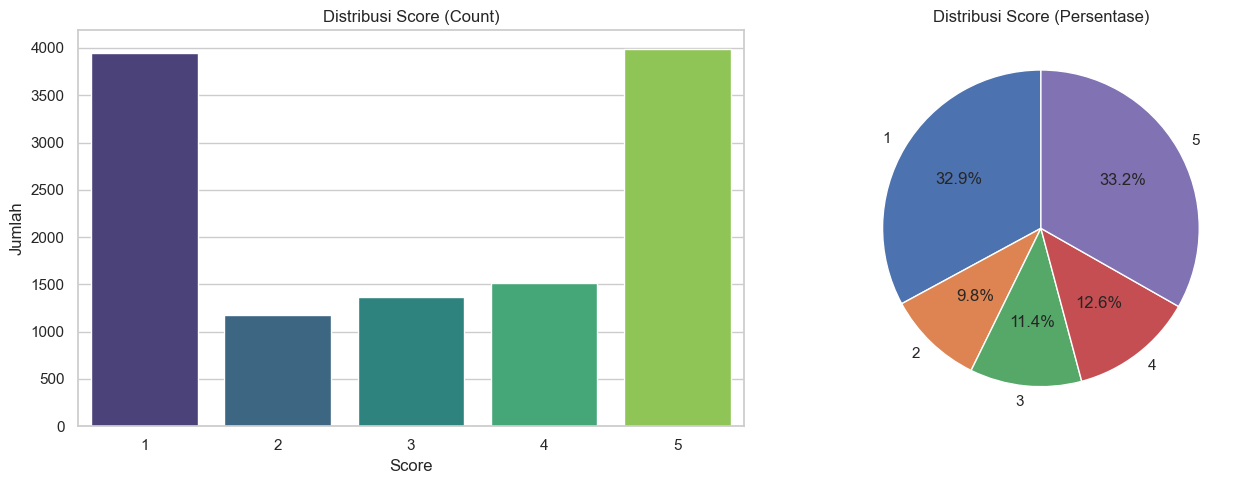

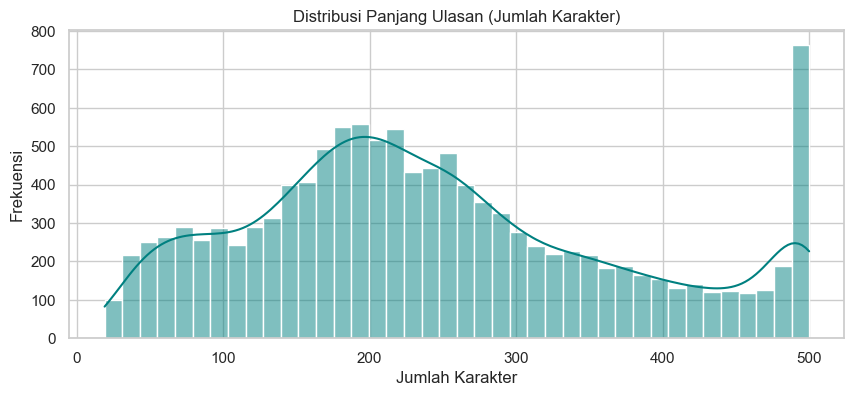

In [ ]:
# ============================================================
# 4) EDA awal + distribusi score
# ============================================================
print('Info dataset:')
display(df.info())

print('\nMissing values:')
display(df.isna().sum().to_frame('missing_count'))

print('\nDuplicate rows:', df.duplicated().sum())

print('\nDistribusi score (count):')
score_count = df['score'].value_counts(dropna=False).sort_index()
display(score_count.to_frame('count'))

print('\nDistribusi score (persentase):')
score_pct = (df['score'].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)
display(score_pct.to_frame('pct'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='score', order=sorted(df['score'].dropna().unique()), ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Score (Count)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Jumlah')

axes[1].pie(score_count.values, labels=[str(x) for x in score_count.index], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribusi Score (Persentase)')

plt.tight_layout()
plt.show()

# Distribusi panjang karakter content
df['char_len'] = df['text'].astype(str).str.len()

plt.figure(figsize=(10, 4))
sns.histplot(df['char_len'], bins=40, kde=True, color='teal')
plt.title('Distribusi Panjang Ulasan (Jumlah Karakter)')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.show()

In [5]:
# ============================================================
# 5) Filtering data
# ============================================================
clean_df = df.copy()

# Drop missing text/score
clean_df = clean_df.dropna(subset=['text', 'score'])

# Drop duplicate text
clean_df['text'] = clean_df['text'].astype(str).str.strip()
clean_df = clean_df[clean_df['text'] != '']
clean_df = clean_df.drop_duplicates(subset=['text'])

# Hanya score valid 1..5
clean_df = clean_df[clean_df['score'].between(1, 5)]
clean_df['score'] = clean_df['score'].astype(int)

print('Shape sesudah filtering:', clean_df.shape)
display(clean_df.head(3))

Shape sesudah filtering: (11999, 3)


,text,score,char_len
0,"game nya seru, developer nya baik, heronya bal...",5,459
1,tolong perbaiki peforma peningkatan sinyal nya...,2,306
2,gamenya udah bagus cuma ada kekurangan di fitu...,2,500


In [10]:
# ============================================================
# 6) Load kamus slang + komponen NLP
# ============================================================
# Bentuk kamus yang didukung:
# - dict: {"gak": "tidak", ...}
# - list of dict: [{"slangword": "gak", "normalisasi": "tidak"}, ...]
with open(SLANG_PATH, 'r', encoding='utf-8') as f:
    slang_raw = json.load(f)


def _normalize_value(val):
    if val is None:
        return ''
    sval = str(val).strip().lower()
    if sval in {'none', 'nan', 'null'}:
        return ''
    return sval


if isinstance(slang_raw, dict):
    SLANG_MAP = {}
    for k, v in slang_raw.items():
        key = _normalize_value(k)
        val = _normalize_value(v)
        if key:
            SLANG_MAP[key] = val if val else key
elif isinstance(slang_raw, list):
    SLANG_MAP = {}
    for row in slang_raw:
        if not isinstance(row, dict):
            continue
        key = _normalize_value(row.get('slangword', ''))
        val = _normalize_value(row.get('normalisasi', ''))
        if key:
            # Jika normalisasi kosong/None, kembalikan token asli
            SLANG_MAP[key] = val if val else key
else:
    raise ValueError('Format file slangwords tidak dikenali.')

print('Jumlah entri slang map:', len(SLANG_MAP))

stemmer = StemmerFactory().create_stemmer()
stop_factory = StopWordRemoverFactory()
STOPWORDS = set(stop_factory.get_stop_words())

# Stopwords tambahan domain
custom_stopwords = {
    'iya', 'yaa', 'gak', 'nya', 'na', 'sih', 'ku', 'di',
    'ga', 'ya', 'gaa', 'loh', 'kah', 'woi', 'yg', 'aja'
}
STOPWORDS = STOPWORDS.union(custom_stopwords)

print('Jumlah stopwords:', len(STOPWORDS))

Jumlah entri slang map: 1098
Jumlah stopwords: 136


In [12]:
# ============================================================
# 7) Definisi fungsi preprocessing teks
# ============================================================
url_re = re.compile(r'https?://\S+|www\.\S+')
mention_re = re.compile(r'@[A-Za-z0-9_]+')
hashtag_re = re.compile(r'#[A-Za-z0-9_]+')
non_letter_re = re.compile(r'[^a-zA-Z\s]')
multispace_re = re.compile(r'\s+')

# Cache stemming agar token yang sama tidak di-stem berulang kali.
STEM_CACHE = {}


def cleaning_text(text: str) -> str:
    text = str(text)
    text = url_re.sub(' ', text)
    text = mention_re.sub(' ', text)
    text = hashtag_re.sub(' ', text)
    text = text.replace('RT', ' ')
    text = non_letter_re.sub(' ', text)
    text = multispace_re.sub(' ', text).strip()
    return text


def casefolding_text(text: str) -> str:
    return str(text).lower().strip()


def fix_slangwords(text: str) -> str:
    tokens = str(text).split()
    normalized = [SLANG_MAP.get(tok, tok) for tok in tokens]
    return ' '.join(normalized)


def tokenize_text(text: str):
    # Tokenizer regex sederhana agar stabil tanpa dependency tambahan.
    return re.findall(r'[a-zA-Z]+', str(text))


def filtering_text(tokens):
    return [tok for tok in tokens if tok not in STOPWORDS and len(tok) > 1]


def stemming_text(tokens):
    stems = []
    for tok in tokens:
        if tok not in STEM_CACHE:
            STEM_CACHE[tok] = stemmer.stem(tok)
        stems.append(STEM_CACHE[tok])
    return stems


def to_sentence(tokens):
    return ' '.join(tokens)


def preprocess_pipeline(raw_text: str) -> str:
    text = cleaning_text(raw_text)
    text = casefolding_text(text)
    text = fix_slangwords(text)
    tokens = tokenize_text(text)
    tokens = filtering_text(tokens)
    tokens = stemming_text(tokens)
    return to_sentence(tokens)

Distribusi label sentiment:


,count
sentiment,
positive,5501
negative,5128
neutral,1370


,pct
sentiment,
positive,45.85
negative,42.74
neutral,11.42


C:\Users\DELL\AppData\Local\Temp\ipykernel_19152\2924490879.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x='sentiment', order=['negative', 'neutral', 'positive'], palette='Set2')


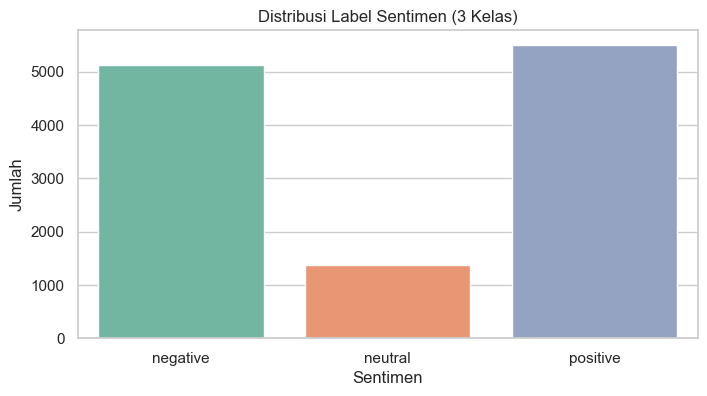

In [8]:
# ============================================================
# 8) Pelabelan sentimen berbasis score polaritas (3 kelas)
# ============================================================
def score_to_sentiment(score: int) -> str:
    if score <= 2:
        return 'negative'
    if score == 3:
        return 'neutral'
    return 'positive'

clean_df['sentiment'] = clean_df['score'].apply(score_to_sentiment)

print('Distribusi label sentiment:')
display(clean_df['sentiment'].value_counts().to_frame('count'))

display(
    (clean_df['sentiment'].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame('pct')
)

plt.figure(figsize=(8, 4))
sns.countplot(data=clean_df, x='sentiment', order=['negative', 'neutral', 'positive'], palette='Set2')
plt.title('Distribusi Label Sentimen (3 Kelas)')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

In [13]:
# ============================================================
# 9) Aplikasikan preprocessing + audit before/after
# ============================================================
work_df = clean_df.copy()
work_df['text_preprocessed'] = work_df['text'].astype(str).apply(preprocess_pipeline)

# Buang baris yang jadi kosong setelah preprocessing
work_df['token_count'] = work_df['text_preprocessed'].str.split().str.len()
work_df = work_df[work_df['token_count'] > 0].copy()

print('Shape setelah preprocessing:', work_df.shape)

sample_preview = work_df[['text', 'text_preprocessed', 'score', 'sentiment']].sample(
    min(5, len(work_df)), random_state=SEED
)
display(sample_preview)

# Cek kata slang yang berhasil dinormalisasi (sampling cepat)
example_tokens = []
for t in work_df['text'].head(200):
    for tok in str(t).lower().split():
        tok = re.sub(r'[^a-zA-Z]', '', tok)
        if tok in SLANG_MAP:
            example_tokens.append((tok, SLANG_MAP[tok]))

print('Contoh normalisasi slang (maks 15):')
for pair in example_tokens[:15]:
    print(pair[0], '->', pair[1])

Shape setelah preprocessing: (11992, 6)


,text,text_preprocessed,score,sentiment
10421,Tarik dulu bintang 5 nya.. habis update season...,tarik dulu bintang habis baru season uda main ...,2,negative
1369,udah bagus sih. tapi tolong lah gausah update ...,baik lah gausah baru terus terus kasihan memo ...,1,negative
1719,sistem nih game udah bagus dari segi matchmaki...,sistem main baik segi matchmaking fitur bagus ...,4,positive
7523,"Untuk match making nya sangat susah,player yan...",tanding making sangat susah main guna bendera ...,3,neutral
360,game nya udh bagus... kalo efek animasi luarny...,main baik kalau efek animasi luar baik cuman s...,3,neutral


Contoh normalisasi slang (maks 15):
game -> permainan
nya -> nya
seru -> seru
nya -> nya
baik -> baik
moba -> genre permainan
lain -> lain
hal -> hal
aku -> saya
kali -> kali
match -> pertandingan
juga -> juga
tim -> tim
cara -> cara
main -> main


In [23]:
# ============================================================
# 11) Prepare data training
# ============================================================
X = work_df['text_preprocessed'].values

# Prioritas label dari score polaritas (leksikon).
# Fallback ke label berbasis score rating jika leksikon tidak tersedia.
if 'sentiment_polarity' in work_df.columns:
    y = work_df['sentiment_polarity'].values
    label_source = 'sentiment_polarity (lexicon polarity score)'
else:
    y = work_df['sentiment'].values
    label_source = 'sentiment (rating score mapping)'

print('Label source:', label_source)

le = LabelEncoder()
y_enc = le.fit_transform(y)

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Jumlah data final:', len(X))

# class weight untuk model yang mendukung
classes = np.unique(y_enc)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_enc)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
print('Class weight:', class_weight_dict)

Label source: sentiment (rating score mapping)
Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Jumlah data final: 11992
Class weight: {0: 0.7799674796747967, 1: 2.9177615571776157, 2: 0.7271845248923655}


In [22]:
# ============================================================
# 11) Utility evaluasi untuk setiap skema
# ============================================================
RESULTS = []


def evaluate_scheme(name, model_pipeline, X_train, X_test, y_train, y_test):
    model_pipeline.fit(X_train, y_train)

    y_pred_train = model_pipeline.predict(X_train)
    y_pred_test = model_pipeline.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    macro_f1 = f1_score(y_test, y_pred_test, average='macro')

    print('=' * 80)
    print(f'{name}')
    print('-' * 80)
    print(f'Train Accuracy : {train_acc:.4f}')
    print(f'Test Accuracy  : {test_acc:.4f}')
    print(f'Macro F1       : {macro_f1:.4f}')

    print('\nClassification Report (Test):')
    print(classification_report(y_test, y_pred_test, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_,
    )
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    RESULTS.append(
        {
            'scheme': name,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'macro_f1': macro_f1,
            'model': model_pipeline,
        }
    )

Skema A - TFIDF Word(1,2) + LinearSVC (80/20)
--------------------------------------------------------------------------------
Train Accuracy : 0.9992
Test Accuracy  : 0.6890
Macro F1       : 0.5636

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.69      0.76      0.72      1025
     neutral       0.29      0.18      0.22       274
    positive       0.75      0.75      0.75      1100

    accuracy                           0.69      2399
   macro avg       0.58      0.56      0.56      2399
weighted avg       0.67      0.69      0.68      2399



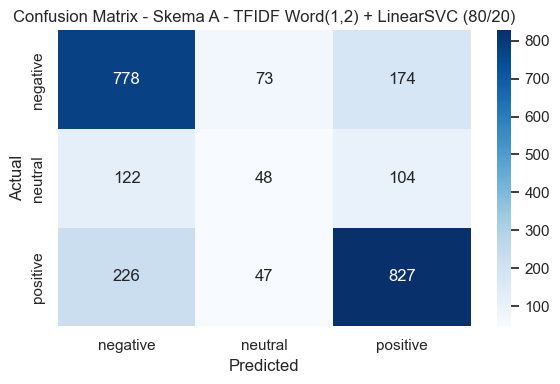

In [16]:
# ============================================================
# 12) Skema A: TF-IDF (word+bigram) + LinearSVC (split 80/20)
# Target utama: >= 92%
# ============================================================
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
)

scheme_a = Pipeline(
    steps=[
        (
            'tfidf',
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                max_features=80000,
                sublinear_tf=True,
            ),
        ),
        ('clf', LinearSVC(C=2.0, class_weight='balanced', random_state=SEED)),
    ]
)

evaluate_scheme('Skema A - TFIDF Word(1,2) + LinearSVC (80/20)', scheme_a, X_train_a, X_test_a, y_train_a, y_test_a)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Skema B - TFIDF Char(3,5) + LogisticRegression (80/20)
--------------------------------------------------------------------------------
Train Accuracy : 0.7909
Test Accuracy  : 0.6248
Macro F1       : 0.5470

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.72      0.65      0.68      1025
     neutral       0.18      0.35      0.24       274
    positive       0.77      0.67      0.72      1100

    accuracy                           0.62      2399
   macro avg       0.56      0.56      0.55      2399
weighted avg       0.68      0.62      0.65      2399



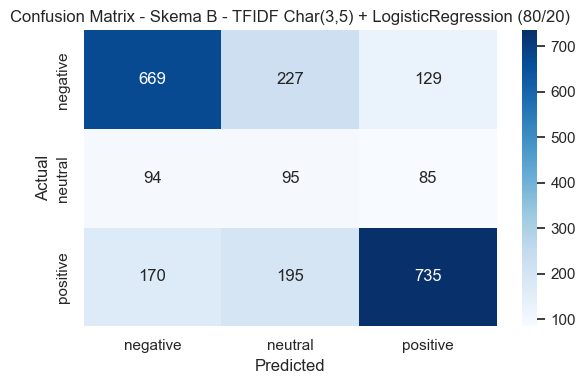

In [17]:
# ============================================================
# 13) Skema B: TF-IDF karakter + Logistic Regression (split 80/20)
# Variasi fitur + algoritma
# ============================================================
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_enc, test_size=0.2, random_state=SEED + 1, stratify=y_enc
)

scheme_b = Pipeline(
    steps=[
        (
            'tfidf',
            TfidfVectorizer(
                analyzer='char_wb',
                ngram_range=(3, 5),
                min_df=2,
                max_features=120000,
                sublinear_tf=True,
            ),
        ),
        (
            'clf',
            LogisticRegression(
                C=3.0,
                solver='saga',
                max_iter=2000,
                class_weight='balanced',
                n_jobs=-1,
                random_state=SEED,
            ),
        ),
    ]
)

evaluate_scheme('Skema B - TFIDF Char(3,5) + LogisticRegression (80/20)', scheme_b, X_train_b, X_test_b, y_train_b, y_test_b)

Skema C - Count(1,2) + ComplementNB (70/30)
--------------------------------------------------------------------------------
Train Accuracy : 0.8825
Test Accuracy  : 0.6948
Macro F1       : 0.5257

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.69      0.79      0.73      1538
     neutral       0.18      0.06      0.09       411
    positive       0.74      0.76      0.75      1649

    accuracy                           0.69      3598
   macro avg       0.54      0.54      0.53      3598
weighted avg       0.66      0.69      0.67      3598



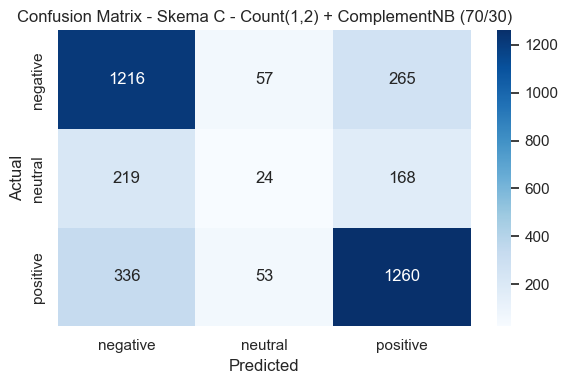

In [18]:
# ============================================================
# 14) Skema C: CountVectorizer + ComplementNB (split 70/30)
# Variasi algoritma + variasi split
# ============================================================
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_enc, test_size=0.3, random_state=SEED + 2, stratify=y_enc
)

scheme_c = Pipeline(
    steps=[
        (
            'count',
            CountVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.98,
                max_features=70000,
            ),
        ),
        ('clf', ComplementNB(alpha=0.3)),
    ]
)

evaluate_scheme('Skema C - Count(1,2) + ComplementNB (70/30)', scheme_c, X_train_c, X_test_c, y_train_c, y_test_c)

In [19]:
# ============================================================
# 15) Ringkasan hasil 3 skema + cek target akurasi
# ============================================================
results_df = pd.DataFrame(RESULTS).drop(columns=['model']).sort_values(
    by=['test_accuracy', 'macro_f1'], ascending=False
)

display(results_df)

best_idx = int(np.argmax([r['test_accuracy'] for r in RESULTS]))
best_result = RESULTS[best_idx]
best_model = best_result['model']

print('Best scheme:', best_result['scheme'])
print('Best train acc:', round(best_result['train_accuracy'], 4))
print('Best test acc :', round(best_result['test_accuracy'], 4))

# Validasi requirement
all_above_85 = all(r['test_accuracy'] >= 0.85 for r in RESULTS)
one_above_92_both = any(
    (r['train_accuracy'] >= 0.92 and r['test_accuracy'] >= 0.92) for r in RESULTS
)

print('\nCek requirement:')
print('Semua skema test >= 0.85          :', all_above_85)
print('Ada 1 skema train & test >= 0.92  :', one_above_92_both)

if not all_above_85 or not one_above_92_both:
    print('\nCatatan: jika requirement belum tercapai, lakukan tuning parameter')
    print('pada C model, ngram_range, max_features, min_df, dan split random_state.')

,scheme,train_accuracy,test_accuracy,macro_f1
2,"Skema C - Count(1,2) + ComplementNB (70/30)",0.882535,0.694830,0.525693
0,"Skema A - TFIDF Word(1,2) + LinearSVC (80/20)",0.999166,0.689037,0.563564
1,"Skema B - TFIDF Char(3,5) + LogisticRegression...",0.790889,0.624844,0.546992


Best scheme: Skema C - Count(1,2) + ComplementNB (70/30)
Best train acc: 0.8825
Best test acc : 0.6948

Cek requirement:
Semua skema test >= 0.85          : False
Ada 1 skema train & test >= 0.92  : False

Catatan: jika requirement belum tercapai, lakukan tuning parameter
pada C model, ngram_range, max_features, min_df, dan split random_state.


In [20]:
# ============================================================
# 16) Inference / testing output kelas kategorikal
# ============================================================
def predict_sentiment(text: str, model, label_encoder):
    processed = preprocess_pipeline(text)
    pred = model.predict([processed])[0]
    label = label_encoder.inverse_transform([pred])[0]
    return processed, label

samples = [
    'game nya seru banget, grafik bagus dan event menarik',
    'matchmaking jelek, sering lag dan force close, kecewa',
    'lumayan sih, kadang bagus kadang ngelag',
    'hero baru keren tapi server sering bermasalah',
    'bagus banget, recommended untuk mabar',
]

rows = []
for txt in samples:
    processed, pred_label = predict_sentiment(txt, best_model, le)
    rows.append(
        {
            'text_raw': txt,
            'text_preprocessed': processed,
            'predicted_sentiment': pred_label,
        }
    )

inference_df = pd.DataFrame(rows)
display(inference_df)

print('Output inference berupa kelas kategorikal: negative / neutral / positive')

,text_raw,text_preprocessed,predicted_sentiment
0,"game nya seru banget, grafik bagus dan event m...",main seru sangat grafik baik acara main tarik,positive
1,"matchmaking jelek, sering lag dan force close,...",matchmaking buruk sering lambat force close ke...,negative
2,"lumayan sih, kadang bagus kadang ngelag",lumayan kadang baik kadang lambat,neutral
3,hero baru keren tapi server sering bermasalah,karakter baru keren server sering masalah,positive
4,"bagus banget, recommended untuk mabar",baik sangat recommended main sama,positive


Output inference berupa kelas kategorikal: negative / neutral / positive
